In [2]:
import pandas as pd

In [3]:
df = pd.read_csv('../data/regression/test.csv')
df.head()

,Hours Studied,Grade on Exam
0,2,69
1,9,98
2,5,82
3,5,77
4,3,71


In [4]:
x = df['Hours Studied']
y = df['Grade on Exam']

x_mean = x.mean()
y_mean = y.mean()

In [5]:
x_mean

np.float64(4.8)

In [6]:
y_mean

np.float64(77.8)

In [7]:
beta1 = ((x - x_mean) * (y - y_mean)).sum() / ((x - x_mean) ** 2).sum()
beta0 = y_mean - beta1 * x_mean

print(f"Mean of X: {x_mean:.2f}")
print(f"Mean of Y: {y_mean:.2f}")
print(f"Intercept (β0): {beta0:.4f}")
print(f"Slope (β1): {beta1:.4f}")
print(f"Fitted line: y_hat = {beta0:.2f} + {beta1:.2f}x")

Mean of X: 4.80
Mean of Y: 77.80
Intercept (β0): 55.0355
Slope (β1): 4.7426
Fitted line: y_hat = 55.04 + 4.74x


$$Y..= \beta_0 + \beta_1 X$$

In [8]:
X = 0

Y_hat = beta0 + beta1*X
print(f'{X} hours of work results {Y_hat}')

0 hours of work results 55.03550295857988


In [9]:
beta1 = 1.5

In [10]:
df.sort_values(by='Hours Studied')

,Hours Studied,Grade on Exam
6,1,55
0,2,69
9,2,64
4,3,71
2,5,82
3,5,77
8,6,84
5,7,84
7,8,94
1,9,98


In [11]:
import pandas as pd
import numpy  as np
from sklearn.linear_model import LinearRegression

ads = pd.read_csv('../data/regression/advertising_and_sales.csv')
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


In [13]:
from sklearn.linear_model import LinearRegression


channels  = ['tv','radio','social_media']


# import statsmodels.api as sm

# X = sm.add_constant(X)   # IMPORTANT: add intercept
# model = sm.OLS(y, X).fit()

# model.rsquared
from utils import rsquered

for channel in channels:

    X = ads[[channel]]
    y = ads['sales']
    
    model = LinearRegression()
    model.fit(X,y)
    
    y_hat = model.predict(X)

    r2 = 1 - rsquered(y,y_hat)
    rmse = np.sqrt(np.mean((y-y_hat)**2))



    print(f'Intercept {channel}: {model.intercept_:2f}')
    print(f'Coef {channel}: {model.coef_[0]:f}')
    print(f'R_Squared {channel}: {r2}')
    print(f'RMSE {channel}: {rmse}')
    print(100*'-')


Intercept tv: -132.492506
Coef tv: 3.561514
R_Squared tv: 0.0010050154760091745
RMSE tv: 2948.5897129351397
----------------------------------------------------------------------------------------------------
Intercept radio: 40586.800679
Coef radio: 8.361628
R_Squared radio: 0.24546834878047163
RMSE radio: 46081.40604818036
----------------------------------------------------------------------------------------------------
Intercept social_media: 118672.571739
Coef social_media: 22.187863
R_Squared social_media: 0.721800271902045
RMSE social_media: 79019.9029555142
----------------------------------------------------------------------------------------------------


$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2$$

In [14]:
corr = ads[['tv','radio','social_media','sales']].corr()
corr

,tv,radio,social_media,sales
tv,1.000000,0.869158,0.527687,0.999497
radio,0.869158,1.000000,0.606338,0.868638
social_media,0.527687,0.606338,1.000000,0.527446
sales,0.999497,0.868638,0.527446,1.000000


In [15]:
import plotly.express as px

fig = px.imshow(corr)
fig.show()

## Multiple Linear Regression

In [ ]:
X = ads[['tv','radio','social_media']]
y = ads['sales']


In [18]:
model = LinearRegression()
model.fit(X,y)

y_hat = model.predict(X)

y_hat

array([ 56855.51571432,  46154.7257576 , 145882.77851125, ...,
       156565.78405758, 252748.49571829, 149455.61837128], shape=(4546,))

In [25]:
from sklearn.metrics import r2_score, root_mean_squared_error

In [22]:
r2 = r2_score(y_true = y, y_pred=y_hat)

In [23]:
rmse = root_mean_squared_error(y_true=y,y_pred=y_hat)

In [24]:
print(f"RMSE: {rmse}")
print(f"R-Squared: {r2}")

RMSE: 2948.5350308251286
R-Squared: 0.9989950218000194


$$Y = \beta_0 + \beta_1 X_1 + \beta_2 X_2 + \beta_3 X_3$$

In [31]:
model.intercept_

np.float64(-133.96296784214792)

In [26]:
model.coef_

array([ 3.56256963, -0.00397038,  0.00496396])

In [37]:
['male', 'famale']

['male', 'famale']

In [ ]:
CASE WHEN MEGA THEN 1 ELSE 0
CASE WEHEN MPLSAPD THEN 1EL S

In [32]:
ads.head()

,tv,radio,social_media,influencer,sales
0,16000.0,6566.23,2907.98,Mega,54732.76
1,13000.0,9237.76,2409.57,Mega,46677.90
2,41000.0,15886.45,2913.41,Mega,150177.83
3,83000.0,30020.03,6922.30,Mega,298246.34
4,15000.0,8437.41,1406.00,Micro,56594.18


$$Y = \beta_0 + \beta_1 macro + \beta_2 micro + \beta_3 nano$$

In [58]:
ads["influencer"] = pd.Categorical(
    ads["influencer"],
    categories=["Mega", "Macro", "Micro", "Nano"]
)

In [59]:
ads.dtypes

tv               float64
radio            float64
social_media     float64
influencer      category
sales            float64
dtype: object

In [60]:
X = pd.get_dummies(ads['influencer'],
               drop_first=True,
               dtype= int
               )


In [52]:
X

,Mega,Micro,Nano
0,1,0,0
1,1,0,0
2,1,0,0
3,1,0,0
4,0,1,0
...,...,...,...
4541,0,1,0
4542,0,0,1
4543,0,1,0
4544,0,0,0


In [53]:
y

0        54732.76
1        46677.90
2       150177.83
3       298246.34
4        56594.18
          ...    
4541     94685.87
4542    249101.92
4543    163631.46
4544    253610.41
4545    148202.41
Name: sales, Length: 4546, dtype: float64

In [54]:
model = LinearRegression()

model.fit(X,y)
# BASELINE category MEGA

,"fit_intercept fit_intercept: bool, default=TrueWhether to calculate the intercept for this model. If setto False, no intercept will be used in calculations(i.e. data is expected to be centered).",True
,"copy_X copy_X: bool, default=TrueIf True, X will be copied; else, it may be overwritten.",True
,"tol tol: float, default=1e-6The precision of the solution (`coef_`) is determined by `tol` whichspecifies a different convergence criterion for the `lsqr` solver.`tol` is set as `atol` and `btol` of :func:`scipy.sparse.linalg.lsqr` whenfitting on sparse training data. This parameter has no effect when fittingon dense data... versionadded:: 1.7",1e-06
,"n_jobs n_jobs: int, default=NoneThe number of jobs to use for the computation. This will only providespeedup in case of sufficiently large problems, that is if firstly`n_targets > 1` and secondly `X` is sparse or if `positive` is setto `True`. ``None`` means 1 unless in a:obj:`joblib.parallel_backend` context. ``-1`` means using allprocessors. See :term:`Glossary ` for more details.",None
,"positive positive: bool, default=FalseWhen set to ``True``, forces the coefficients to be positive. Thisoption is only supported for dense arrays.For a comparison between a linear regression model with positive constraintson the regression coefficients and a linear regression without such constraints,see :ref:`sphx_glr_auto_examples_linear_model_plot_nnls.py`... versionadded:: 0.24",False


In [56]:
model.coef_


array([-5653.24247589, -4487.78011412, -4357.32328636])

In [57]:
model.intercept_

np.float64(196066.15030575538)

$$Y = \beta_0 + \beta_1 X_1

## Time Series

In [41]:
import glob
import os

In [42]:
import pandas as pd
import numpy as np
from sklearn.linear_model import LinearRegression
from os.path import join

PATH = '../data/regression/time_series/'

In [43]:
file_full_names = glob.glob(join(PATH,'*.csv'))
file_full_names

['../data/regression/time_series/gold_prices_2025_2026.csv',
 '../data/regression/time_series/gold_prices_2024_2025.csv',
 '../data/regression/time_series/gold_prices_2022_2023.csv',
 '../data/regression/time_series/gold_prices_2023_2024.csv']

In [46]:
base_names =  [os.path.basename(i).split(".")[0] for i in file_full_names]
base_names

['gold_prices_2025_2026',
 'gold_prices_2024_2025',
 'gold_prices_2022_2023',
 'gold_prices_2023_2024']

In [55]:
file_full_names[1:]

['../data/regression/time_series/gold_prices_2024_2025.csv',
 '../data/regression/time_series/gold_prices_2022_2023.csv',
 '../data/regression/time_series/gold_prices_2023_2024.csv']

In [68]:
dfs =  [pd.read_csv(i, parse_dates=['Date']) for i in file_full_names[1:]]

ts_combined_2022_2025 = pd.concat(dfs) # up to 2026
ts_combined_2025_2026 = pd.read_csv(file_full_names[0], parse_dates=['Date']) #from 2025_2026

# քանի որ սեսսսսնց , ապե հանում եմ ենք վերլուծ


In [69]:
print(ts_combined_2022_2025.dtypes)
print(100*"-") 
print(ts_combined_2025_2026.dtypes)

Date     datetime64[us]
Open                str
High                str
Low                 str
Close               str
dtype: object
----------------------------------------------------------------------------------------------------
Date     datetime64[us]
Open                str
High                str
Low                 str
Close               str
dtype: object


In [70]:
ts_combined_2022_2025["Close"] = (
    ts_combined_2022_2025["Close"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

ts_combined_2022_2025["Close"] = pd.to_numeric(ts_combined_2022_2025["Close"], errors="coerce")

In [71]:
ts_combined_2025_2026["Close"] = (
    ts_combined_2025_2026["Close"]
    .astype(str)
    .str.replace(",", "", regex=False)
    .str.strip()
)

ts_combined_2025_2026["Close"] = pd.to_numeric(ts_combined_2025_2026["Close"], errors="coerce")

In [72]:
print(ts_combined_2022_2025.dtypes)
print(100*"-") 
print(ts_combined_2025_2026.dtypes)

Date     datetime64[us]
Open                str
High                str
Low                 str
Close           float64
dtype: object
----------------------------------------------------------------------------------------------------
Date     datetime64[us]
Open                str
High                str
Low                 str
Close           float64
dtype: object


In [73]:
ts_combined_2022_2025 = ts_combined_2022_2025.sort_values(by='Date')

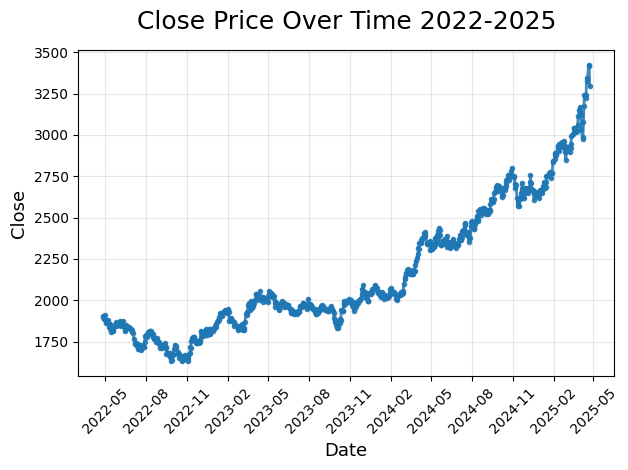

In [75]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


plt.plot(
    ts_combined_2022_2025["Date"],
    ts_combined_2022_2025["Close"],
    linewidth=2,
    marker="o",
    markersize=3,
    alpha=0.85
)

plt.title("Close Price Over Time 2022-2025", fontsize=18, pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Close", fontsize=13)

# Improve x-axis date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Reduce number of y-axis labels
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

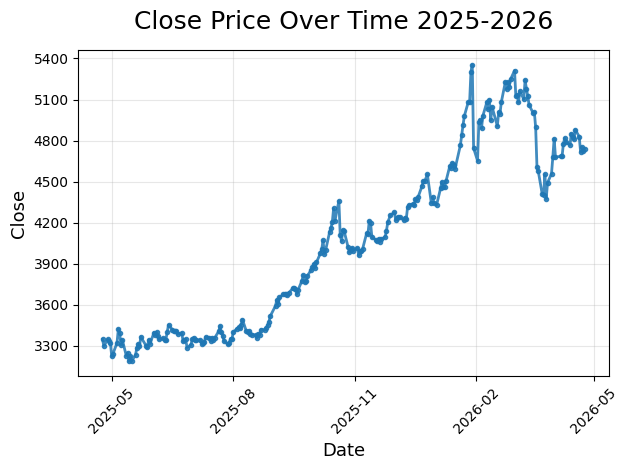

In [77]:
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
from matplotlib.ticker import MaxNLocator


plt.plot(
    ts_combined_2025_2026["Date"],
    ts_combined_2025_2026["Close"],
    linewidth=2,
    marker="o",
    markersize=3,
    alpha=0.85
)

plt.title("Close Price Over Time 2025-2026", fontsize=18, pad=15)
plt.xlabel("Date", fontsize=13)
plt.ylabel("Close", fontsize=13)

# Improve x-axis date formatting
plt.gca().xaxis.set_major_locator(mdates.MonthLocator(interval=3))
plt.gca().xaxis.set_major_formatter(mdates.DateFormatter("%Y-%m"))

# Reduce number of y-axis labels
plt.gca().yaxis.set_major_locator(MaxNLocator(nbins=8))

plt.xticks(rotation=45)
plt.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [81]:
ts_combined_2022_2025["time_index"] = np.arange(1, len(ts_combined_2022_2025) + 1)
ts_combined_2022_2025.tail() #754

,Date,Open,High,Low,Close,time_index
4,2025-04-16,"3,248.40","3,358.40","3,245.20",3346.4,750
3,2025-04-17,"3,357.50","3,371.90","3,296.40",3328.4,751
2,2025-04-21,"3,347.00","3,442.30","3,344.00",3425.3,752
1,2025-04-22,"3,435.10","3,509.90","3,379.10",3419.4,753
0,2025-04-23,"3,367.70","3,396.00","3,270.80",3294.1,754


In [82]:
X_time = ts_combined_2022_2025[["time_index"]]
y_time = ts_combined_2022_2025["Close"]


In [83]:

trend_model = LinearRegression()
trend_model.fit(X_time, y_time)

trend_pred = trend_model.predict(X_time)

trend_r2 = r2_score(y_time, trend_pred)
trend_rmse =root_mean_squared_error(y_time, trend_pred)

In [84]:
print(f"Intercept: {trend_model.intercept_:.2f}")
print(f"Slope: {trend_model.coef_[0]:.4f}")
print(f"R-squared: {trend_r2:.4f}")
print(f"RMSE: {trend_rmse:.4f}")

Intercept: 1533.84
Slope: 1.6701
R-squared: 0.8454
RMSE: 155.4725


In [95]:
ts_combined_2025_2026["time_index"] = np.arange(start = 755 ,stop=len(ts_combined_2025_2026) + 1+754, step=1)
ts_combined_2025_2026.head()

,Date,Open,High,Low,Close,time_index
0,2026-04-24,"4,715.60","4,757.10","4,672.20",4740.9,755
1,2026-04-23,"4,759.20","4,771.30","4,680.10",4724.0,756
2,2026-04-22,"4,738.70","4,790.80","4,733.10",4753.0,757
3,2026-04-21,"4,842.40","4,854.80","4,685.80",4719.6,758
4,2026-04-20,"4,811.80","4,847.90","4,748.00",4828.8,759


In [96]:
ts_combined_2025_2026.tail()

,Date,Open,High,Low,Close,time_index
249,2025-04-30,"3,324.50","3,337.60","3,275.60",3319.1,1004
250,2025-04-29,"3,354.90","3,359.30","3,309.20",3333.6,1005
251,2025-04-28,"3,336.50","3,363.80","3,278.00",3347.7,1006
252,2025-04-25,"3,362.00","3,384.10","3,274.80",3298.4,1007
253,2025-04-24,"3,301.80","3,377.00","3,301.30",3348.6,1008


In [103]:
# PREDICTTING THE Future
y_hat = trend_model.predict(ts_combined_2025_2026[['time_index']])
y_actual = ts_combined_2025_2026[['Close']]

In [104]:

trend_rmse_future = root_mean_squared_error(y_hat, y_actual)

print(f'RMSE on Test: {trend_rmse_future}')
print(f'RMSE on Train: {trend_rmse}')

# trend_r2 = r2_score(y_time, trend_pred)


RMSE on Test: 1291.456833059585
RMSE on Train: 155.4724567564181


In [106]:
from statsmodels.tsa.arima.model import ARIMA

ts_arima = ts_combined_2022_2025.set_index("Date").asfreq("B")

ts_arima.head()


,Open,High,Low,Close,time_index
Date,,,,,
2022-04-25,"1,931.90","1,935.50","1,891.80",1896.0,1.0
2022-04-26,"1,899.80","1,912.20","1,896.30",1904.1,2.0
2022-04-27,"1,907.40","1,908.10","1,881.60",1888.7,3.0
2022-04-28,"1,886.80","1,897.80","1,870.90",1891.3,4.0
2022-04-29,"1,895.80","1,921.30","1,893.50",1911.7,5.0


In [112]:
ts_arima.tail()

,Open,High,Low,Close,time_index
Date,,,,,
2025-04-17,"3,357.50","3,371.90","3,296.40",3328.4,751.0
2025-04-18,NaN,NaN,NaN,NaN,NaN
2025-04-21,"3,347.00","3,442.30","3,344.00",3425.3,752.0
2025-04-22,"3,435.10","3,509.90","3,379.10",3419.4,753.0
2025-04-23,"3,367.70","3,396.00","3,270.80",3294.1,754.0


In [ ]:
combinations = [(1, 1, 1),(2, 2, 2)]

for i in combinations:
    arima_model = ARIMA(ts_arima["Close"], order= i )
    arima_fit = arima_model.fit()
    arima_forecast = arima_fit.forecast(steps=3)
    print('calculating RMSE:')
    print(50*"-",i,50*"-")
    print(arima_forecast)



-------------------------------------------------- (1, 1, 1) --------------------------------------------------
2025-04-24    3291.022529
2025-04-25    3291.332953
2025-04-28    3291.301641
Freq: B, Name: predicted_mean, dtype: float64
-------------------------------------------------- (2, 2, 2) --------------------------------------------------
2025-04-24    3295.249007
2025-04-25    3301.608962
2025-04-28    3303.326545
Freq: B, Name: predicted_mean, dtype: float64


In [110]:
arima_model = ARIMA(ts_arima["Close"], order=(1, 1, 1))
arima_fit = arima_model.fit()

arima_forecast = arima_fit.forecast(steps=10)

In [111]:
arima_forecast

2025-04-24    3291.022529
2025-04-25    3291.332953
2025-04-28    3291.301641
2025-04-29    3291.304799
2025-04-30    3291.304481
2025-05-01    3291.304513
2025-05-02    3291.304510
2025-05-05    3291.304510
2025-05-06    3291.304510
2025-05-07    3291.304510
Freq: B, Name: predicted_mean, dtype: float64

In [114]:
ts_combined_2025_2026.tail(10)

,Date,Open,High,Low,Close,time_index
244,2025-05-07,"3,448.10","3,448.20","3,367.00",3391.9,999
245,2025-05-06,"3,345.70","3,444.50","3,332.10",3422.8,1000
246,2025-05-05,"3,247.10","3,346.70","3,243.10",3322.3,1001
247,2025-05-02,"3,247.60","3,277.00","3,229.50",3243.3,1002
248,2025-05-01,"3,299.00","3,300.60","3,209.40",3222.2,1003
249,2025-04-30,"3,324.50","3,337.60","3,275.60",3319.1,1004
250,2025-04-29,"3,354.90","3,359.30","3,309.20",3333.6,1005
251,2025-04-28,"3,336.50","3,363.80","3,278.00",3347.7,1006
252,2025-04-25,"3,362.00","3,384.10","3,274.80",3298.4,1007
253,2025-04-24,"3,301.80","3,377.00","3,301.30",3348.6,1008


[Prophet Documentation](https://facebook.github.io/prophet/docs/seasonality,_holiday_effects,_and_regressors.html)

In [121]:
from prophet import Prophet

df_prophet = ts_combined_2022_2025.rename(columns={"Date": "ds", "Close": "y"})

prophet_model = Prophet()
prophet_model.fit(df_prophet)

future = prophet_model.make_future_dataframe(periods=5, freq="B")

forecast = prophet_model.predict(future)

forecast[["ds", "yhat", "yhat_lower", "yhat_upper"]].tail(3)

21:08:56 - cmdstanpy - INFO - Chain [1] start processing
21:08:56 - cmdstanpy - INFO - Chain [1] done processing


,ds,yhat,yhat_lower,yhat_upper
756,2025-04-28,3263.148152,3209.578045,3317.379318
757,2025-04-29,3267.908652,3215.927418,3317.730074
758,2025-04-30,3268.862512,3218.216626,3323.448072


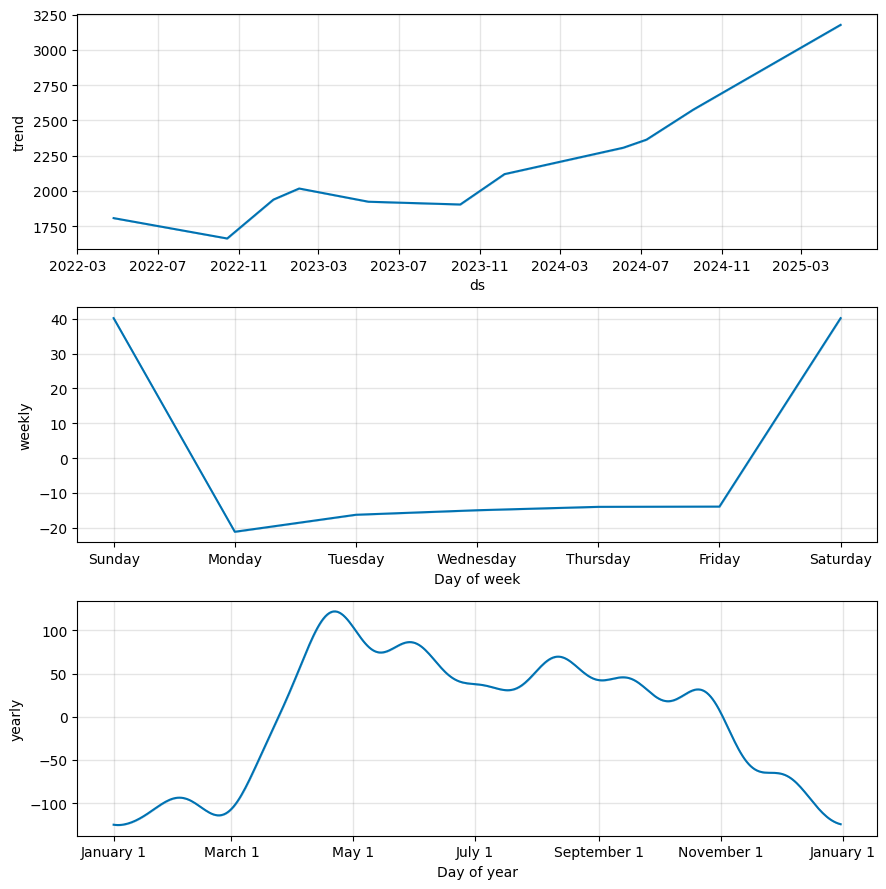

In [122]:
prophet_model.plot_components(forecast)
plt.show()

## Synthetic Customer Churn Dataset and End-to-End Logistic Regression Case

In this section, we will:

- create a **realistic synthetic churn dataset**
- define **true underlying coefficients (betas)**
- simulate churn using the **logistic function**
- train a logistic regression model
- interpret results using coefficients, odds ratios, a confusion matrix, and a simple revenue matrix


## Creating Synthetic Customer Data


In [ ]:
import numpy as np
import pandas as pd

np.random.seed(42)

n = 1000

df_churn = pd.DataFrame({
    "tenure": np.random.randint(1, 36, n),
    "monthly_charges": np.random.uniform(20, 120, n),
    "support_calls": np.random.randint(0, 10, n),
    "contract_type": np.random.choice([0, 1], n)  # 0 = month-to-month, 1 = long-term
})

df_churn.head()


## Defining True Relationship (Betas)


In [ ]:
beta_0 = -3
beta_tenure = -0.05
beta_monthly = 0.02
beta_calls = 0.5
beta_contract = -1.0


## Generating Churn Probability


In [ ]:
z = (
    beta_0
    + beta_tenure * df_churn["tenure"]
    + beta_monthly * df_churn["monthly_charges"]
    + beta_calls * df_churn["support_calls"]
    + beta_contract * df_churn["contract_type"]
)

p = 1 / (1 + np.exp(-z))

df_churn["churn_probability"] = p
df_churn["churn"] = (np.random.rand(n) < p).astype(int)

df_churn.head()


## Train Logistic Regression Model


In [ ]:
try:
    from sklearn.model_selection import train_test_split
    from sklearn.linear_model import LogisticRegression
    sklearn_available = True
except ModuleNotFoundError:
    sklearn_available = False


def sigmoid(values):
    values = np.clip(values, -500, 500)
    return 1 / (1 + np.exp(-values))


class SimpleLogisticRegression:
    def __init__(self, learning_rate=0.001, n_iter=20000):
        self.learning_rate = learning_rate
        self.n_iter = n_iter
        self.coef_ = None
        self.intercept_ = None

    def fit(self, X, y):
        X_values = np.asarray(X, dtype=float)
        y_values = np.asarray(y, dtype=float)

        means = X_values.mean(axis=0)
        stds = X_values.std(axis=0)
        stds[stds == 0] = 1
        X_scaled = (X_values - means) / stds

        weights = np.zeros(X_scaled.shape[1])
        intercept = 0.0

        for _ in range(self.n_iter):
            probabilities = sigmoid(intercept + X_scaled @ weights)
            error = probabilities - y_values
            intercept -= self.learning_rate * error.mean()
            weights -= self.learning_rate * (X_scaled.T @ error) / len(y_values)

        self.feature_means_ = means
        self.feature_stds_ = stds
        self.scaled_coef_ = weights
        self.scaled_intercept_ = intercept
        self.coef_ = np.array([weights / stds])
        self.intercept_ = np.array([intercept - np.sum(weights * means / stds)])
        return self

    def predict_proba(self, X):
        X_values = np.asarray(X, dtype=float)
        X_scaled = (X_values - self.feature_means_) / self.feature_stds_
        probabilities = sigmoid(self.scaled_intercept_ + X_scaled @ self.scaled_coef_)
        return np.column_stack([1 - probabilities, probabilities])


def stratified_train_test_split(X, y, test_size=0.2, random_state=42):
    rng = np.random.default_rng(random_state)
    y_values = np.asarray(y)
    train_indices = []
    test_indices = []

    for value in np.unique(y_values):
        indices = np.where(y_values == value)[0]
        rng.shuffle(indices)
        n_test = int(round(len(indices) * test_size))
        test_indices.extend(indices[:n_test])
        train_indices.extend(indices[n_test:])

    rng.shuffle(train_indices)
    rng.shuffle(test_indices)

    return (
        X.iloc[train_indices],
        X.iloc[test_indices],
        y.iloc[train_indices],
        y.iloc[test_indices]
    )


X = df_churn[["tenure", "monthly_charges", "support_calls", "contract_type"]]
y = df_churn["churn"]

if sklearn_available:
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42,
        stratify=y
    )
    model = LogisticRegression(max_iter=1000)
else:
    X_train, X_test, y_train, y_test = stratified_train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )
    model = SimpleLogisticRegression()

model.fit(X_train, y_train)

probs = model.predict_proba(X_test)[:, 1]
preds = (probs >= 0.5).astype(int)


## Interpreting Coefficients


In [ ]:
coef_df = pd.DataFrame({
    "feature": X.columns,
    "beta": model.coef_[0],
    "exp_beta": np.exp(model.coef_[0])
})

coef_df


### Interpretation


In [ ]:
odds_ratios = coef_df.set_index("feature")["exp_beta"]

print(f"Tenure changes churn odds by a factor of {odds_ratios['tenure']:.2f}.")
print(f"Monthly charges change churn odds by a factor of {odds_ratios['monthly_charges']:.2f}.")
print(f"Each additional support call changes churn odds by a factor of {odds_ratios['support_calls']:.2f}.")
print(f"Long-term contract type changes churn odds by a factor of {odds_ratios['contract_type']:.2f}.")


## Confusion Matrix


In [ ]:
try:
    from sklearn.metrics import confusion_matrix
except ModuleNotFoundError:
    def confusion_matrix(y_true, y_pred):
        y_true = np.asarray(y_true)
        y_pred = np.asarray(y_pred)
        return np.array([
            [np.sum((y_true == 0) & (y_pred == 0)), np.sum((y_true == 0) & (y_pred == 1))],
            [np.sum((y_true == 1) & (y_pred == 0)), np.sum((y_true == 1) & (y_pred == 1))]
        ])

cm = confusion_matrix(y_test, preds)
tn, fp, fn, tp = cm.ravel()

cm_df = pd.DataFrame(
    cm,
    index=["Actual non-churn", "Actual churn"],
    columns=["Predicted non-churn", "Predicted churn"]
)

cm_df


### Interpretation


In [ ]:
print(f"Correctly predicted churn (TP): {tp}")
print(f"Incorrectly predicted churn (FP): {fp}")
print(f"Missed churn (FN): {fn}")
print(f"Correctly predicted non-churn (TN): {tn}")


## Revenue Matrix (Retention Strategy)

### Business Assumptions


In [ ]:
cost = 10
benefit = 50


### Profit Calculation


In [ ]:
profit = (
    tp * (benefit - cost)
    - fp * cost
)

profit


### Interpretation


In [ ]:
print(f"Customers correctly saved: {tp}, generating {tp * (benefit - cost)} revenue.")
print(f"Unnecessary contacts: {fp}, costing {fp * cost}.")
print(f"Net profit from strategy: {profit}.")


## Final Insight

- Features with odds ratio greater than 1 increase churn risk.
- Features with odds ratio less than 1 reduce churn risk.
- Model decisions directly translate into the business outcome calculated above.

Logistic regression is not just predictive; it is **decision-driven analytics**.
